### Importing Libraries

In [ ]:
# Importing Important libraries
import numpy as np
import pandas as pd
import os
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import (
    VGG16, ResNet50, MobileNet, InceptionV3, EfficientNetB0
)
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_pre
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing The DataSet
train_dir =r'C:/Users/91886/Desktop/My Computer/Project_guvi/Fish Identfication Deep Learning/data/train'
val_dir = r'C:/Users/91886/Desktop/My Computer/Project_guvi/Fish Identfication Deep Learning/data/val'
test_dir = r'C:/Users/91886/Desktop/My Computer/Project_guvi/Fish Identfication Deep Learning/data/test'

### Data Preprocessing & Augmentation

In [5]:
# Resize for training
IMG_SIZE = (224,224)
BATCH = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", shuffle=True, seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
with open("class_indices.json","w") as f:
    json.dump(train_gen.class_indices,f)


Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.


### Model Training - CNN from scratch 

In [7]:
# Define CNN model
def make_cnn_scratch():
    inputs = layers.Input(shape=(224,224,3))
    x = layers.Conv2D(32,3,activation="relu",padding="same")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64,3,activation="relu",padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128,3,activation="relu",padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256,activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES,activation="softmax")(x)
    model = models.Model(inputs,outputs)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

cnn_model = make_cnn_scratch()
ckpt = callbacks.ModelCheckpoint("cnn_scratch_best.h5",monitor="val_accuracy",save_best_only=True,mode="max")
es = callbacks.EarlyStopping(monitor="val_accuracy",patience=5,restore_best_weights=True)
history_cnn = cnn_model.fit(train_gen,validation_data=val_gen,epochs=20,callbacks=[ckpt,es])

Epoch 1/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3269 - loss: 1.9631

195/195 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.3276 - loss: 1.9610 - val_accuracy: 0.6896 - val_loss: 0.9396
Epoch 2/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6381 - loss: 1.0213

195/195 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.6382 - loss: 1.0210 - val_accuracy: 0.7711 - val_loss: 0.6547
Epoch 3/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7218 - loss: 0.7655

195/195 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.7218 - loss: 0.7655 - val_accuracy: 0.8462 - val_loss: 0.4940
Epoch 4/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7819 - loss: 0.6174

195/195 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - accuracy: 0.7820 - loss: 0.6172 - val_accuracy: 0.8929 - val_loss: 0.3286
Epoch 5/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8364 - loss: 0.4761

195/195 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8364 - loss: 0.4761 - val_accuracy: 0.9222 - val_loss: 0.2733
Epoch 6/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8727 - loss: 0.3654

195/195 ━━━━━━━━━━━━━━━━━━━━ 499s 3s/step - accuracy: 0.8727 - loss: 0.3654 - val_accuracy: 0.9286 - val_loss: 0.2585
Epoch 7/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8675 - loss: 0.3919

195/195 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.8675 - loss: 0.3917 - val_accuracy: 0.9350 - val_loss: 0.2103
Epoch 8/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8964 - loss: 0.3014

195/195 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.8965 - loss: 0.3012 - val_accuracy: 0.9551 - val_loss: 0.1505
Epoch 9/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9226 - loss: 0.2200

195/195 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.9226 - loss: 0.2200 - val_accuracy: 0.9789 - val_loss: 0.0997
Epoch 10/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 7497s 39s/step - accuracy: 0.9281 - loss: 0.2137 - val_accuracy: 0.9789 - val_loss: 0.0876
Epoch 11/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.9450 - loss: 0.1691 - val_accuracy: 0.9771 - val_loss: 0.0847
Epoch 12/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - accuracy: 0.9408 - loss: 0.1867 - val_accuracy: 0.9744 - val_loss: 0.1341
Epoch 13/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.9437 - loss: 0.1723 - val_accuracy: 0.9441 - val_loss: 0.1939
Epoch 14/20
195/195 ━━━━━━━━━━━━━━━━━━━━ 289s 1s/step - accuracy: 0.9355 - loss: 0.1813 - val_accuracy: 0.9634 - val_loss: 0.1535


### Transfer Learning Models

In [8]:

MODEL_SPECS = {
    "VGG16": {"fn": VGG16, "pre": vgg_pre, "size": (224,224)},
    "ResNet50": {"fn": ResNet50, "pre": resnet_pre, "size": (224,224)},
    "MobileNet": {"fn": MobileNet, "pre": mobilenet_pre, "size": (224,224)},
    "InceptionV3": {"fn": InceptionV3, "pre": inception_pre, "size": (299,299)},
    "EfficientNetB0": {"fn": EfficientNetB0, "pre": eff_pre, "size": (224,224)},
}

def build_transfer(name,num_classes):
    spec = MODEL_SPECS[name]
    base = spec["fn"](weights="imagenet",include_top=False,input_shape=(*spec["size"],3))
    base.trainable = False
    inputs = layers.Input(shape=(*spec["size"],3))
    x = layers.Lambda(spec["pre"])(inputs)
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes,activation="softmax")(x)
    model = models.Model(inputs,outputs)
    model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
    return model, spec["size"]

results = {}
for name in MODEL_SPECS.keys():
    model, size = build_transfer(name,NUM_CLASSES)
    train_g = train_datagen.flow_from_directory(train_dir,target_size=size,batch_size=BATCH,class_mode="categorical",shuffle=True,seed=SEED)
    val_g = val_test_datagen.flow_from_directory(val_dir,target_size=size,batch_size=BATCH,class_mode="categorical",shuffle=False)
    ckpt = callbacks.ModelCheckpoint(f"{name}_best.h5",monitor="val_accuracy",save_best_only=True,mode="max")
    es = callbacks.EarlyStopping(monitor="val_accuracy",patience=5,restore_best_weights=True)
    hist = model.fit(train_g,validation_data=val_g,epochs=15,callbacks=[ckpt,es])
    results[name] = {"model": model,"history": hist.history,"size": size}

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1154 - loss: 2.9478

195/195 ━━━━━━━━━━━━━━━━━━━━ 1213s 6s/step - accuracy: 0.1154 - loss: 2.9461 - val_accuracy: 0.1712 - val_loss: 2.3152
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1386s 7s/step - accuracy: 0.1435 - loss: 2.3618 - val_accuracy: 0.1712 - val_loss: 2.3155
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1670s 9s/step - accuracy: 0.1563 - loss: 2.3191 - val_accuracy: 0.1712 - val_loss: 2.3123
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1645s 8s/step - accuracy: 0.1592 - loss: 2.3192 - val_accuracy: 0.1712 - val_loss: 2.3147
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1447s 7s/step - accuracy: 0.1763 - loss: 2.2953 - val_accuracy: 0.1667 - val_loss: 2.3324
Epoch 6/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1313s 7s/step - accuracy: 0.1718 - loss: 2.2991 - val_accuracy: 0.1712 - val_loss: 2.3117
Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1242 - loss: 2.4223

195/195 ━━━━━━━━━━━━━━━━━━━━ 705s 3s/step - accuracy: 0.1243 - loss: 2.4219 - val_accuracy: 0.2088 - val_loss: 2.2705
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1910 - loss: 2.2632

195/195 ━━━━━━━━━━━━━━━━━━━━ 547s 3s/step - accuracy: 0.1910 - loss: 2.2631 - val_accuracy: 0.2299 - val_loss: 2.1779
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 562s 3s/step - accuracy: 0.2089 - loss: 2.1934 - val_accuracy: 0.2207 - val_loss: 2.1431
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2272 - loss: 2.1496

195/195 ━━━━━━━━━━━━━━━━━━━━ 637s 3s/step - accuracy: 0.2272 - loss: 2.1496 - val_accuracy: 0.2839 - val_loss: 2.0820
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2292 - loss: 2.1266

...

195/195 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.3299 - loss: 1.8746 - val_accuracy: 0.4451 - val_loss: 1.7482
Epoch 7/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.3505 - loss: 1.8604 - val_accuracy: 0.4432 - val_loss: 1.7289
Epoch 8/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.3545 - loss: 1.8377 - val_accuracy: 0.3974 - val_loss: 1.7318
Epoch 9/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.3596 - loss: 1.8082 - val_accuracy: 0.4121 - val_loss: 1.7093
Epoch 10/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3824 - loss: 1.7843

195/195 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.3825 - loss: 1.7843 - val_accuracy: 0.4670 - val_loss: 1.6542
Epoch 11/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3779 - loss: 1.7774

195/195 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.3779 - loss: 1.7774 - val_accuracy: 0.4853 - val_loss: 1.6344
Epoch 12/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.3891 - loss: 1.7712 - val_accuracy: 0.4505 - val_loss: 1.6188
Epoch 13/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.4006 - loss: 1.7289 - val_accuracy: 0.4679 - val_loss: 1.6010
Epoch 14/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4030 - loss: 1.7297

195/195 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.4031 - loss: 1.7296 - val_accuracy: 0.5092 - val_loss: 1.5743
Epoch 15/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.4210 - loss: 1.6941 - val_accuracy: 0.5000 - val_loss: 1.5678
Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.1557 - loss: 2.3365

195/195 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.1556 - loss: 2.3365 - val_accuracy: 0.1712 - val_loss: 2.3247
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.1606 - loss: 2.3315 - val_accuracy: 0.1712 - val_loss: 2.3121
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.1581 - loss: 2.3293 - val_accuracy: 0.1053 - val_loss: 2.3313
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.1507 - loss: 2.3255 - val_accuracy: 0.1328 - val_loss: 2.3331
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.1629 - loss: 2.3248 - val_accuracy: 0.1712 - val_loss: 2.3319
Epoch 6/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.1613 - loss: 2.3242 - val_accuracy: 0.1712 - val_loss: 2.3311


### Model Evaluation

In [ ]:

MODEL_SPECS = {
    "VGG16": {"fn": VGG16, "pre": vgg_pre, "size": (224,224)},
    "ResNet50": {"fn": ResNet50, "pre": resnet_pre, "size": (224,224)},
    "MobileNet": {"fn": MobileNet, "pre": mobilenet_pre, "size": (224,224)},
    "InceptionV3": {"fn": InceptionV3, "pre": inception_pre, "size": (299,299)},
    "EfficientNetB0": {"fn": EfficientNetB0, "pre": eff_pre, "size": (224,224)},
}

def build_transfer(name,num_classes):
    spec = MODEL_SPECS[name]
    base = spec["fn"](weights="imagenet",include_top=False,input_shape=(*spec["size"],3))
    base.trainable = False
    inputs = layers.Input(shape=(*spec["size"],3))
    x = layers.Lambda(spec["pre"])(inputs)
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes,activation="softmax")(x)
    model = models.Model(inputs,outputs)
    model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
    return model, spec["size"]

results = {}
for name in MODEL_SPECS.keys():
    model, size = build_transfer(name,NUM_CLASSES)
    train_g = train_datagen.flow_from_directory(train_dir,target_size=size,batch_size=BATCH,class_mode="categorical",shuffle=True,seed=SEED)
    val_g = val_test_datagen.flow_from_directory(val_dir,target_size=size,batch_size=BATCH,class_mode="categorical",shuffle=False)
    ckpt = callbacks.ModelCheckpoint(f"{name}_best.h5",monitor="val_accuracy",save_best_only=True,mode="max")
    es = callbacks.EarlyStopping(monitor="val_accuracy",patience=5,restore_best_weights=True)
    hist = model.fit(train_g,validation_data=val_g,epochs=15,callbacks=[ckpt,es])
    results[name] = {"model": model,"history": hist.history,"size": size}

Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1154 - loss: 2.9478

195/195 ━━━━━━━━━━━━━━━━━━━━ 1213s 6s/step - accuracy: 0.1154 - loss: 2.9461 - val_accuracy: 0.1712 - val_loss: 2.3152
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1386s 7s/step - accuracy: 0.1435 - loss: 2.3618 - val_accuracy: 0.1712 - val_loss: 2.3155
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1670s 9s/step - accuracy: 0.1563 - loss: 2.3191 - val_accuracy: 0.1712 - val_loss: 2.3123
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1645s 8s/step - accuracy: 0.1592 - loss: 2.3192 - val_accuracy: 0.1712 - val_loss: 2.3147
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1447s 7s/step - accuracy: 0.1763 - loss: 2.2953 - val_accuracy: 0.1667 - val_loss: 2.3324
Epoch 6/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 1313s 7s/step - accuracy: 0.1718 - loss: 2.2991 - val_accuracy: 0.1712 - val_loss: 2.3117
Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1242 - loss: 2.4223

195/195 ━━━━━━━━━━━━━━━━━━━━ 705s 3s/step - accuracy: 0.1243 - loss: 2.4219 - val_accuracy: 0.2088 - val_loss: 2.2705
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1910 - loss: 2.2632

195/195 ━━━━━━━━━━━━━━━━━━━━ 547s 3s/step - accuracy: 0.1910 - loss: 2.2631 - val_accuracy: 0.2299 - val_loss: 2.1779
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 562s 3s/step - accuracy: 0.2089 - loss: 2.1934 - val_accuracy: 0.2207 - val_loss: 2.1431
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2272 - loss: 2.1496

195/195 ━━━━━━━━━━━━━━━━━━━━ 637s 3s/step - accuracy: 0.2272 - loss: 2.1496 - val_accuracy: 0.2839 - val_loss: 2.0820
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2292 - loss: 2.1266

...

195/195 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.2816 - loss: 2.0207 - val_accuracy: 0.3434 - val_loss: 1.9403
Epoch 12/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.2814 - loss: 2.0176 - val_accuracy: 0.3306 - val_loss: 1.9262
Epoch 13/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.2787 - loss: 1.9821 - val_accuracy: 0.3370 - val_loss: 1.9426
Epoch 14/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 421s 2s/step - accuracy: 0.2784 - loss: 1.9985 - val_accuracy: 0.2912 - val_loss: 1.9480
Epoch 15/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2799 - loss: 2.0003

195/195 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.2799 - loss: 2.0003 - val_accuracy: 0.3443 - val_loss: 1.9114
Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - accuracy: 0.1442 - loss: 2.3730

195/195 ━━━━━━━━━━━━━━━━━━━━ 197s 992ms/step - accuracy: 0.1443 - loss: 2.3728 - val_accuracy: 0.1712 - val_loss: 2.3066
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 175s 895ms/step - accuracy: 0.1601 - loss: 2.3071 - val_accuracy: 0.1712 - val_loss: 2.2850
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 164s 839ms/step - accuracy: 0.1900 - loss: 2.2773 - val_accuracy: 0.1712 - val_loss: 2.2818
Epoch 4/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 168s 859ms/step - accuracy: 0.1782 - loss: 2.2798 - val_accuracy: 0.1712 - val_loss: 2.2645
Epoch 5/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 168s 862ms/step - accuracy: 0.1860 - loss: 2.2669 - val_accuracy: 0.1712 - val_loss: 2.2523
Epoch 6/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 176s 900ms/step - accuracy: 0.1893 - loss: 2.2402 - val_accuracy: 0.1712 - val_loss: 2.2314
Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Epoch 1/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1664 - loss: 2.3029

195/195 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.1665 - loss: 2.3025 - val_accuracy: 0.2152 - val_loss: 2.0888
Epoch 2/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2472 - loss: 2.0992

195/195 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.2472 - loss: 2.0991 - val_accuracy: 0.3425 - val_loss: 1.9635
Epoch 3/15
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2870 - loss: 2.0177

### Model Evaluation

In [35]:
def evaluate_model(path,size):
    m = tf.keras.models.load_model(path)
    gen = val_test_datagen.flow_from_directory(test_dir,target_size=size,batch_size=BATCH,class_mode="categorical",shuffle=False)
    probs = m.predict(gen)
    y_pred = probs.argmax(1)
    y_true = gen.classes
    acc = accuracy_score(y_true,y_pred)
    prec,rec,f1,_ = precision_recall_fscore_support(y_true,y_pred,average="weighted",zero_division=0)
    cm = confusion_matrix(y_true,y_pred)
    print(f"\nReport for {path}:")
    print(classification_report(y_true,y_pred,target_names=list(train_gen.class_indices.keys())))
    return acc,prec,rec,f1,cm

metrics = {}
# CNN scratch
metrics["CNN"] = evaluate_model("cnn_scratch_best.h5",(224,224))
# Pretrained
for name,spec in MODEL_SPECS.items():
    metrics[name] = evaluate_model(f"{name}_best.h5",spec["size"])

Found 3187 images belonging to 11 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 441ms/step

Report for cnn_scratch_best.h5:
                                  precision    recall  f1-score   support

                     animal fish       0.98      0.99      0.99       520
                animal fish bass       0.50      0.08      0.13        13
   fish sea_food black_sea_sprat       0.99      1.00      0.99       298
   fish sea_food gilt_head_bream       0.99      0.92      0.95       305
   fish sea_food hourse_mackerel       0.98      1.00      0.99       286
        fish sea_food red_mullet       1.00      1.00      1.00       291
     fish sea_food red_sea_bream       0.99      0.95      0.97       273
          fish sea_food sea_bass       0.94      0.98      0.96       327
            fish sea_food shrimp       0.97      1.00      0.98       289
fish sea_food striped_red_mullet       0.97      0.96      0.97       293
             fish sea_food trout       0.99      1.00      0.99  

TypeError: Could not locate function 'preprocess_input'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'preprocess_input', 'registered_name': 'function'}

### Save Best Model

In [37]:
best_model = max(metrics.items(), key=lambda x: x[1][0])  # pick by accuracy
best_name = best_model[0]
print("\nBest model:",best_name,"Accuracy:",best_model[1][0])

# save metadata
meta = {"best_model": best_name,"metrics": metrics[best_name]}
with open("best_model.pkl","wb") as f:
    pickle.dump(meta,f)


Best model: CNN Accuracy: 0.9777219956071541


### Visualization

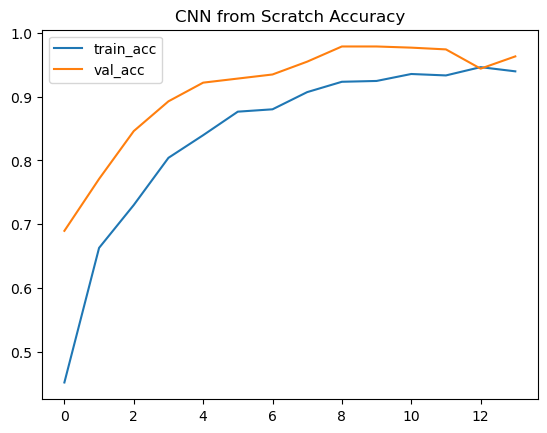

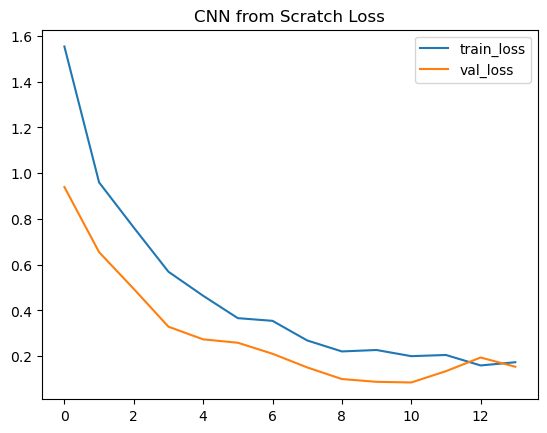

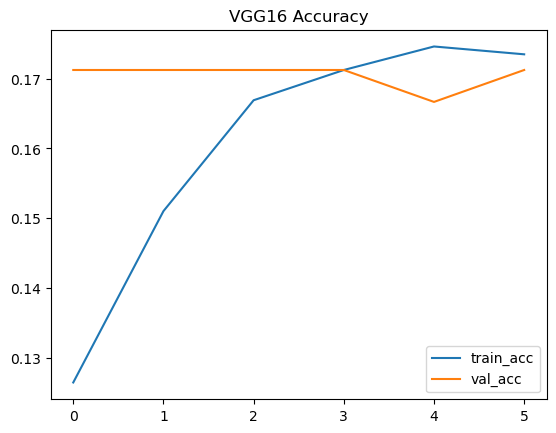

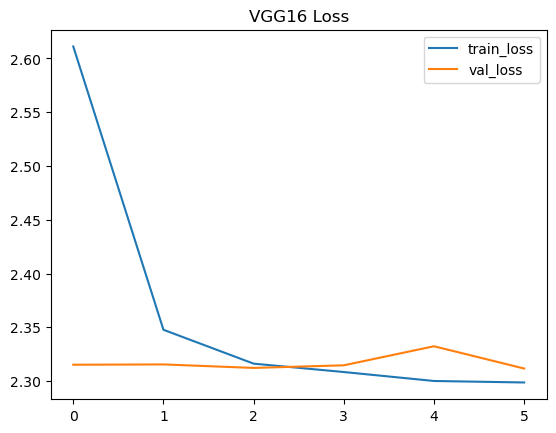

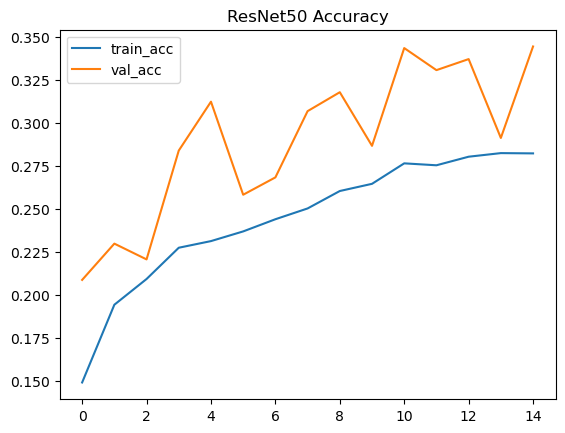

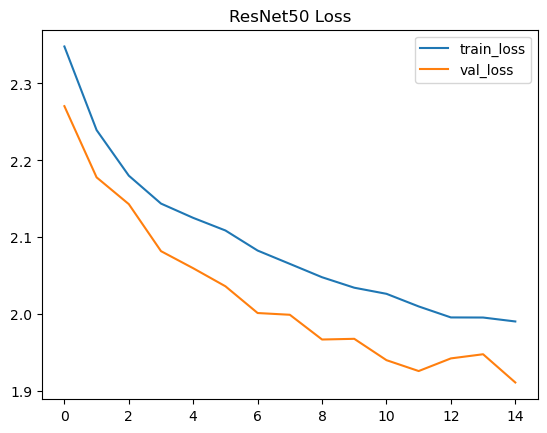

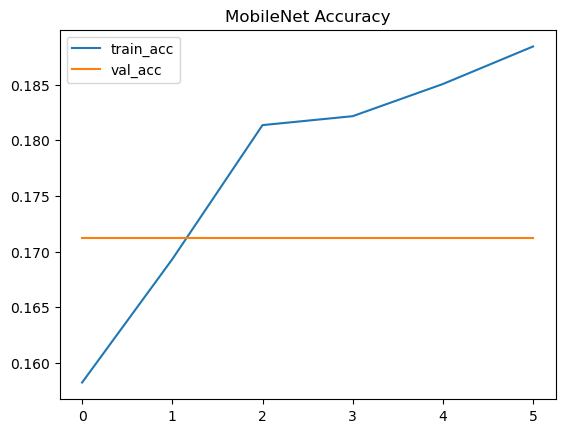

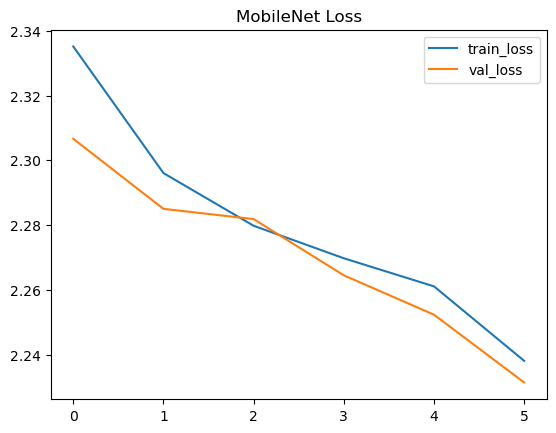

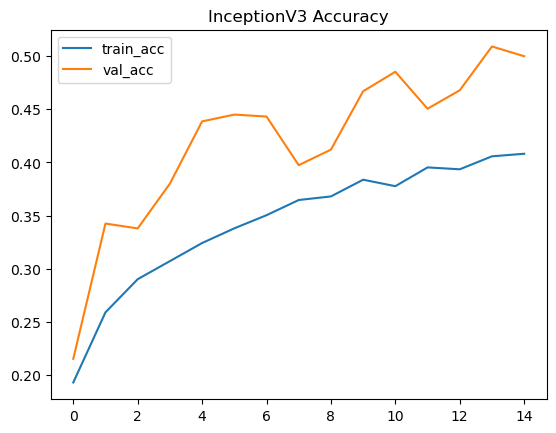

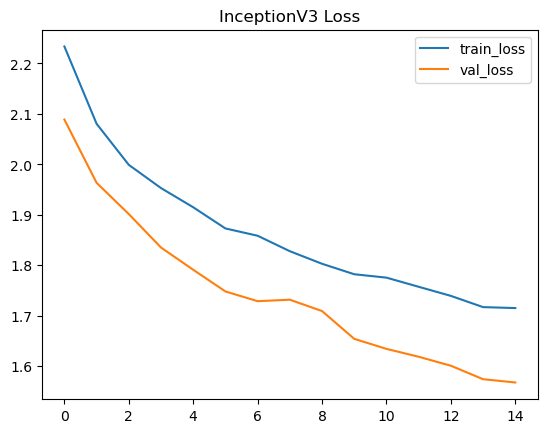

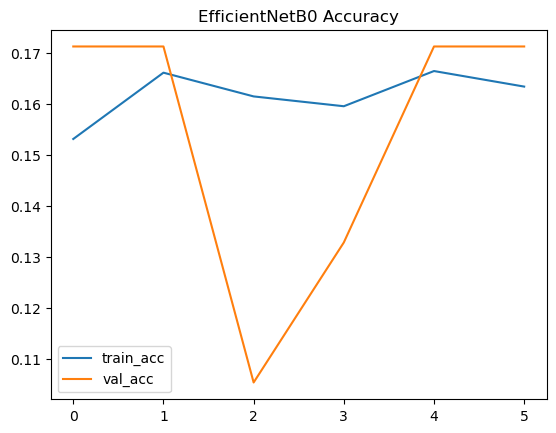

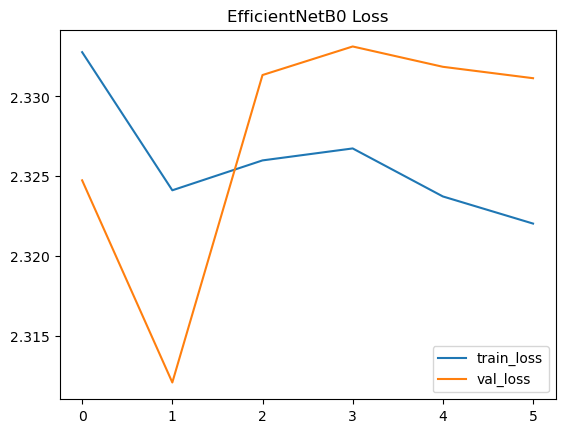

In [15]:
def plot_history(h,title=""):
    plt.plot(h["accuracy"],label="train_acc")
    plt.plot(h["val_accuracy"],label="val_acc")
    plt.title(title + " Accuracy"); plt.legend(); plt.show()
    plt.plot(h["loss"],label="train_loss")
    plt.plot(h["val_loss"],label="val_loss")
    plt.title(title + " Loss"); plt.legend(); plt.show()

plot_history(history_cnn.history,"CNN from Scratch")
for name in results.keys():
    plot_history(results[name]["history"],name)

In [21]:
# 1. Extended history plot
def plot_history(h, title=""):
    # Accuracy
    plt.figure(figsize=(6,4))
    plt.plot(h["accuracy"], label="Train Accuracy")
    plt.plot(h["val_accuracy"], label="Val Accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Val Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# 2. Confusion matrix
def plot_confusion(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# 3. Classification report heatmap
def plot_classification_report(y_true, y_pred, class_names):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    plt.figure(figsize=(8,6))
    sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="YlGnBu")
    plt.title("Classification Report (Precision, Recall, F1)")
    plt.show()

# 4. ROC Curve (for multi-class softmax models)
def plot_roc(y_true, y_proba, n_classes):
    fpr, tpr, roc_auc = {}, {}, {}
    y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=n_classes)
    
    plt.figure(figsize=(8,6))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
    
    for i, color in zip(range(n_classes), colors):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='Class %d (AUC = %0.2f)' % (i, roc_auc[i]))
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-class ROC Curve")
    plt.legend(loc="lower right")
    plt.show()